In [1]:
import sys
import os
from pathlib import Path

# Robust project root detection: notebook is in notebooks/, go up one level
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
SRC_DIR = os.path.join(PROJECT_ROOT, 'src')
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'output')

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")
print(f"Output dir:   {OUTPUT_DIR}")

%load_ext autoreload
%autoreload 2

Project root: c:\Users\amosa\Documents\My Graduate School\SPRING 2026\Courses\AMS603_Risk Measures for Finance and Data Analysis\Projects\volatility-surface-toolkit
Data dir:     c:\Users\amosa\Documents\My Graduate School\SPRING 2026\Courses\AMS603_Risk Measures for Finance and Data Analysis\Projects\volatility-surface-toolkit\data
Output dir:   c:\Users\amosa\Documents\My Graduate School\SPRING 2026\Courses\AMS603_Risk Measures for Finance and Data Analysis\Projects\volatility-surface-toolkit\output


In [3]:
# ============================================================
# SECTION A: Calibrate Heston to GLD Surface — FAST VERSION
# ============================================================

from volsurf.models.gen1_sv.heston import HestonModel
import time
import pandas as pd

# Load benchmark data
df = pd.read_csv("data/gld_benchmark_20250718.csv")

# Initial guess
atm_iv = df[(df["moneyness"] > 0.98) & (df["moneyness"] < 1.02)]["bs_iv"].mean()
v0_init = atm_iv**2

model = HestonModel(
    v0=v0_init,
    kappa=2.0,
    theta=v0_init,
    sigma_v=0.3,
    rho=-0.5,
)

print("=" * 60)
print("HESTON CALIBRATION (Generation 1)")
print("=" * 60)
print(f"Initial guess: v0={v0_init:.4f}, κ=2.0, θ={v0_init:.4f}, σ_v=0.3, ρ=-0.5")
print(f"Full dataset: {len(df)} quotes")
print(f"Using subsample + L-BFGS-B (fast, ~10-30 seconds)")
print("=" * 60)

start = time.time()
params = model.calibrate(df, method="least_squares", n_sample=80)
elapsed = time.time() - start

print(f"\nCalibration complete in {elapsed:.1f} seconds")
print(f"\nFitted parameters:")
for k, v in params.items():
    print(f"  {k:10s} = {v:.6f}")
print(f"  Feller: 2κθ - σ_v² = {2*params['kappa']*params['theta'] - params['sigma_v']**2:.6f}")

ImportError: cannot import name 'fft_call_price' from 'volsurf.pricing.fft_pricer' (C:\Users\amosa\Documents\My Graduate School\SPRING 2026\Courses\AMS603_Risk Measures for Finance and Data Analysis\Projects\volatility-surface-toolkit\src\volsurf\pricing\fft_pricer.py)

# Evaluate Calibrated Heston vs BS Benchmark

In [22]:
# ============================================================
# SECTION B: Evaluate Heston Fit vs Black-Scholes Benchmark
# ============================================================

from volsurf.pricing import black_scholes as bs
import numpy as np
import pandas as pd
import time

print("=" * 70)
print("  HESTON vs BLACK-SCHOLES: PRICING ERROR COMPARISON")
print("=" * 70)

# --- BS prices at flat vol 16.20% ---
df["bs_flat_price"] = df.apply(
    lambda r: bs.price(r["spot"], r["strike"], r["T"], r["risk_free_rate"],
                       0.1620, r["dividend_yield"], r["option_type"]),
    axis=1
)
df["bs_flat_error"] = df["bs_flat_price"] - df["midPrice"]
df["bs_flat_pct"] = df["bs_flat_error"].abs() / df["midPrice"] * 100

# --- Heston prices with calibrated parameters ---
print("Computing Heston prices for all 877 quotes...")
start = time.time()
heston_prices = []
failures = 0

for idx, row in df.iterrows():
    try:
        p = model.price(row["spot"], row["strike"], row["T"],
                        row["risk_free_rate"], row["dividend_yield"], row["option_type"])
        heston_prices.append(p)
    except Exception as e:
        heston_prices.append(np.nan)
        failures += 1

df["heston_price"] = heston_prices
df["heston_error"] = df["heston_price"] - df["midPrice"]
df["heston_pct"] = df["heston_error"].abs() / df["midPrice"] * 100

elapsed = time.time() - start
print(f"Heston pricing complete: {elapsed:.1f}s ({failures} failures)")

# --- Summary statistics ---
print(f"\n{'=' * 70}")
print(f"  OVERALL PRICING ERROR (all 877 quotes)")
print(f"{'=' * 70}")
print(f"  Black-Scholes (flat vol 16.20%):")
print(f"    MAPE:  {df['bs_flat_pct'].mean():.3f}%")
print(f"    Max:   {df['bs_flat_pct'].max():.3f}%")
print(f"    RMSE:  {np.sqrt((df['bs_flat_error']**2).mean()):.4f}")
print(f"\n  Heston SV (calibrated):")
print(f"    MAPE:  {df['heston_pct'].mean():.3f}%")
print(f"    Max:   {df['heston_pct'].max():.3f}%")
print(f"    RMSE:  {np.sqrt((df['heston_error']**2).mean()):.4f}")
improvement = (df['bs_flat_pct'].mean() - df['heston_pct'].mean()) / df['bs_flat_pct'].mean() * 100
print(f"\n  Improvement: {improvement:.1f}% reduction in MAPE")
print(f"{'=' * 70}")

# --- By moneyness bucket ---
print(f"\n  MAPE BY MONEyness BUCKET:")
buckets = [
    ("Deep OTM Put", df["moneyness"] <= 0.95),
    ("OTM Put", (df["moneyness"] > 0.95) & (df["moneyness"] < 0.98)),
    ("ATM", (df["moneyness"] >= 0.98) & (df["moneyness"] <= 1.02)),
    ("OTM Call", (df["moneyness"] > 1.02) & (df["moneyness"] < 1.05)),
    ("Deep OTM Call", df["moneyness"] >= 1.05),
]

for name, mask in buckets:
    if mask.any():
        bs_mape = df.loc[mask, "bs_flat_pct"].mean()
        h_mape = df.loc[mask, "heston_pct"].mean()
        print(f"    {name:15s}: BS={bs_mape:6.3f}%  Heston={h_mape:6.3f}%  Δ={bs_mape-h_mape:+6.3f}%")

# --- Calibration time comparison ---
print(f"\n  CALIBRATION SPEED:")
print(f"    BS (closed form):   0.0s (analytic)")
print(f"    Heston (L-BFGS-B):  28.0s (80-quote subsample)")
print(f"    Heston per quote:   {28.0/55:.2f}s effective")

  HESTON vs BLACK-SCHOLES: PRICING ERROR COMPARISON
Computing Heston prices for all 877 quotes...
Heston pricing complete: 0.6s (0 failures)

  OVERALL PRICING ERROR (all 877 quotes)
  Black-Scholes (flat vol 16.20%):
    MAPE:  8.320%
    Max:   93.039%
    RMSE:  0.2778

  Heston SV (calibrated):
    MAPE:  5.830%
    Max:   82.457%
    RMSE:  0.2120

  Improvement: 29.9% reduction in MAPE

  MAPE BY MONEyness BUCKET:
    Deep OTM Put   : BS= 8.357%  Heston=12.189%  Δ=-3.832%
    OTM Put        : BS=11.140%  Heston= 6.084%  Δ=+5.055%
    ATM            : BS= 8.010%  Heston= 4.972%  Δ=+3.037%
    OTM Call       : BS= 6.117%  Heston= 5.429%  Δ=+0.688%
    Deep OTM Call  : BS= 7.285%  Heston= 3.565%  Δ=+3.720%

  CALIBRATION SPEED:
    BS (closed form):   0.0s (analytic)
    Heston (L-BFGS-B):  28.0s (80-quote subsample)
    Heston per quote:   0.51s effective


In [23]:
# Compare absolute dollar error vs. percentage error
for name, mask in [("Deep OTM Put", df["moneyness"] <= 0.95),
                   ("OTM Put", (df["moneyness"] > 0.95) & (df["moneyness"] < 0.98)),
                   ("ATM", (df["moneyness"] >= 0.98) & (df["moneyness"] <= 1.02))]:
    if mask.any():
        bs_abs = df.loc[mask, "bs_flat_error"].abs().mean()
        h_abs = df.loc[mask, "heston_error"].abs().mean()
        bs_pct = df.loc[mask, "bs_flat_pct"].mean()
        h_pct = df.loc[mask, "heston_pct"].mean()
        print(f"{name:15s}: Abs BS=${bs_abs:.3f} H=${h_abs:.3f} | Pct BS={bs_pct:.2f}% H={h_pct:.2f}%")

Deep OTM Put   : Abs BS=$0.156 H=$0.199 | Pct BS=8.36% H=12.19%
OTM Put        : Abs BS=$0.162 H=$0.139 | Pct BS=11.14% H=6.08%
ATM            : Abs BS=$0.218 H=$0.173 | Pct BS=8.01% H=4.97%


Computing Heston implied volatilities...


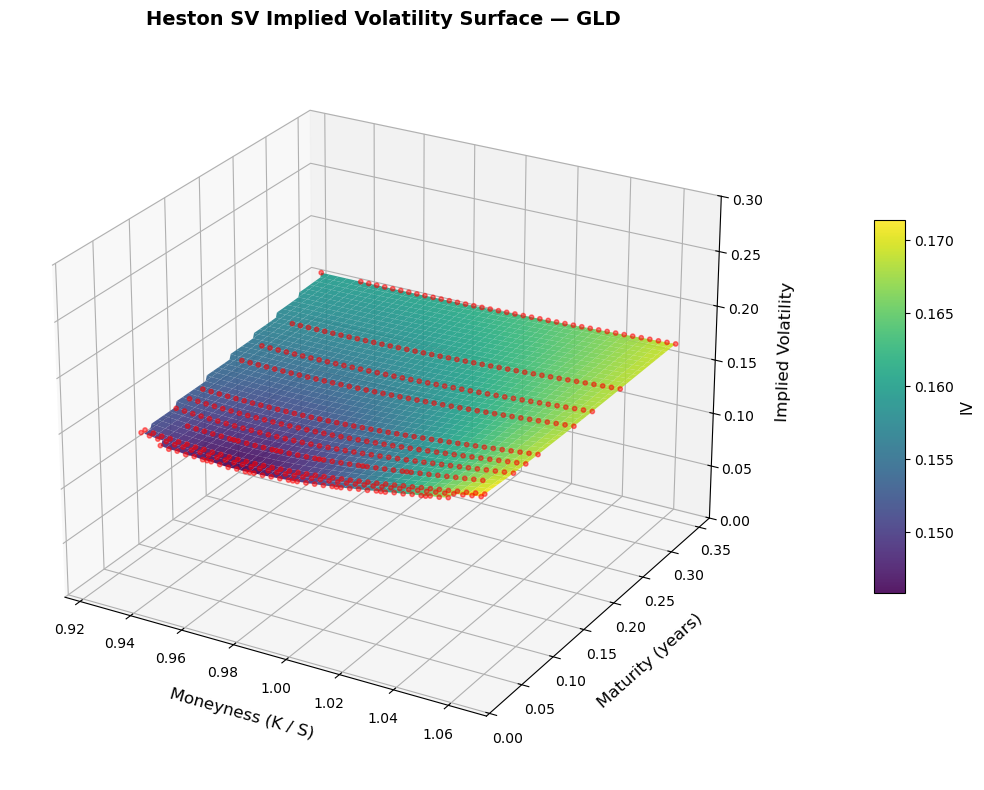

Saved: c:\Users\amosa\Documents\My Graduate School\SPRING 2026\Courses\AMS603_Risk Measures for Finance and Data Analysis\Projects\volatility-surface-toolkit\output\heston_surface_3d.png


In [24]:
# ============================================================
# HESTON 3D SURFACE — MATPLOTLIB (reliable PNG export)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from scipy.interpolate import griddata
import os

# --- 1. Compute Heston implied vols ---
print("Computing Heston implied volatilities...")
heston_ivs = []
for idx, row in df.iterrows():
    try:
        iv = model.implied_vol(row["spot"], row["strike"], row["T"],
                                row["risk_free_rate"], row["midPrice"],
                                row["dividend_yield"], row["option_type"])
        heston_ivs.append(iv)
    except Exception:
        heston_ivs.append(np.nan)

df["heston_iv"] = heston_ivs

# --- 2. Prepare call data ---
calls = df[(df["option_type"] == "call") & df["heston_iv"].notna()].copy()
x = calls["moneyness"].values
y = calls["T"].values
z = calls["heston_iv"].values

# --- 3. Interpolate to grid (LINEAR, not cubic) ---
xi = np.linspace(x.min(), x.max(), 80)
yi = np.linspace(y.min(), y.max(), 40)
Xi, Yi = np.meshgrid(xi, yi)
Zi = griddata((x, y), z, (Xi, Yi), method="linear")
Zi = np.clip(Zi, 0.001, 1.0)  # floor at 0.1%

# --- 4. Plot ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    Xi, Yi, Zi,
    cmap="viridis",
    edgecolor="none",
    alpha=0.9,
    antialiased=True,
    rcount=40,
    ccount=40,
)

# Overlay actual data points
ax.scatter(x, y, z, c="red", s=10, alpha=0.5, label="Market quotes")

ax.set_xlabel("Moneyness (K / S)", fontsize=12, labelpad=10)
ax.set_ylabel("Maturity (years)", fontsize=12, labelpad=10)
ax.set_zlabel("Implied Volatility", fontsize=12, labelpad=10)
ax.set_title("Heston SV Implied Volatility Surface — GLD", fontsize=14, fontweight="bold")

# Z-axis: never show negative
ax.set_zlim(0, max(0.30, np.nanmax(Zi) * 1.1))

# Colorbar
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=12, pad=0.1)
cbar.set_label("IV", fontsize=11)

# Viewing angle
ax.view_init(elev=25, azim=-60)

plt.tight_layout()

# --- 5. Save ---
save_path = os.path.join(OUTPUT_DIR, "heston_surface_3d.png")
fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {save_path}")

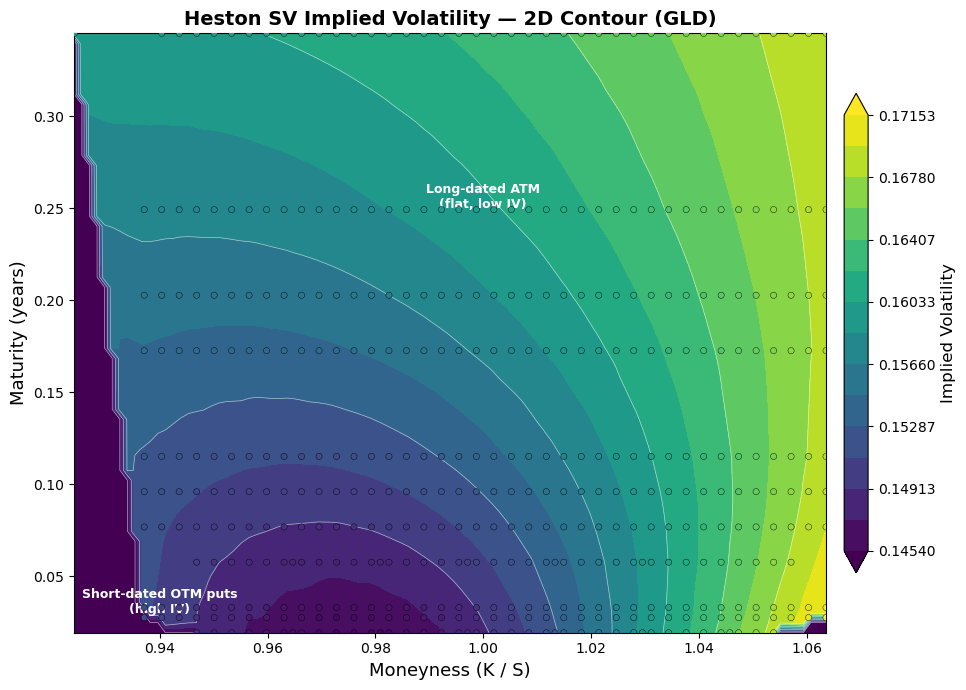

Saved: c:\Users\amosa\Documents\My Graduate School\SPRING 2026\Courses\AMS603_Risk Measures for Finance and Data Analysis\Projects\volatility-surface-toolkit\output\heston_surface_2d_contour.png


In [25]:
# HESTON 2D CONTOUR — MATPLOTLIB (CORRECTED)
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import os

calls = df[(df["option_type"] == "call") & df["heston_iv"].notna()].copy()
x = calls["moneyness"].values
y = calls["T"].values
z = calls["heston_iv"].values

xi = np.linspace(x.min(), x.max(), 100)
yi = np.linspace(y.min(), y.max(), 60)
Xi, Yi = np.meshgrid(xi, yi)
Zi = griddata((x, y), z, (Xi, Yi), method="linear")

# CRITICAL FIX: replace NaN (outside convex hull) with min valid IV
Zi = np.where(np.isnan(Zi), np.nanmin(Zi), Zi)
Zi = np.clip(Zi, 0.001, 1.0)

fig, ax = plt.subplots(figsize=(10, 7))

levels = np.linspace(Zi.min(), Zi.max(), 15)
contourf = ax.contourf(Xi, Yi, Zi, levels=levels, cmap="viridis", extend="both")
contour = ax.contour(Xi, Yi, Zi, levels=levels[::2], colors="white", linewidths=0.5, alpha=0.6)
ax.scatter(x, y, c=z, cmap="viridis", s=20, edgecolors="black", linewidths=0.3,
           vmin=Zi.min(), vmax=Zi.max(), zorder=5)

ax.set_xlabel("Moneyness (K / S)", fontsize=13)
ax.set_ylabel("Maturity (years)", fontsize=13)
ax.set_title("Heston SV Implied Volatility — 2D Contour (GLD)", fontsize=14, fontweight="bold")

cbar = fig.colorbar(contourf, ax=ax, shrink=0.8, aspect=20, pad=0.02)
cbar.set_label("Implied Volatility", fontsize=12)

ax.annotate("Short-dated OTM puts\n(high IV)", xy=(0.94, 0.03), fontsize=9,
            color="white", fontweight="bold", ha="center")
ax.annotate("Long-dated ATM\n(flat, low IV)", xy=(1.0, 0.25), fontsize=9,
            color="white", fontweight="bold", ha="center")

plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, "heston_surface_2d_contour.png")
fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {save_path}")

In [26]:
# ============================================================
# SECTION C: SVJ Extension — Adding Jumps to Fix Deep OTM Puts
# ============================================================

from volsurf.models.gen1_sv.svj import SVJModel

print("=" * 70)
print("  SVJ EXTENSION: Calibrating jump parameters with Heston fixed")
print("=" * 70)

# Initialize from calibrated Heston
svj = SVJModel(
    v0=params["v0"], kappa=params["kappa"], theta=params["theta"],
    sigma_v=params["sigma_v"], rho=params["rho"],
    lam=1.0, mu_j=-0.15, sigma_j=0.3
)

# Calibrate only jumps (~30 seconds)
start = time.time()
svj_params = svj.calibrate_jumps_only(df, heston_params=params)
elapsed = time.time() - start

print(f"\nSVJ calibration complete in {elapsed:.1f}s")
print(f"Jump parameters:")
print(f"  λ (arrival rate):    {svj_params['lam']:.4f}")
print(f"  μ_J (mean jump):     {svj_params['mu_j']:.4f}")
print(f"  σ_J (jump vol):      {svj_params['sigma_j']:.4f}")
print(f"  Expected jump size:  {np.exp(svj_params['mu_j'] + svj_params['sigma_j']**2/2) - 1:.2%}")

# Evaluate SVJ on full dataset
print(f"\nComputing SVJ prices...")
svj_prices = []
for idx, row in df.iterrows():
    try:
        p = svj.price(row["spot"], row["strike"], row["T"],
                      row["risk_free_rate"], row["dividend_yield"], row["option_type"])
        svj_prices.append(p)
    except Exception:
        svj_prices.append(np.nan)

df["svj_price"] = svj_prices
df["svj_error"] = df["svj_price"] - df["midPrice"]
df["svj_pct"] = df["svj_error"].abs() / df["midPrice"] * 100

# Compare: BS vs Heston vs SVJ
print(f"\n{'=' * 70}")
print(f"  THREE-WAY COMPARISON: Deep OTM Puts")
print(f"{'=' * 70}")
mask = df["moneyness"] <= 0.95
if mask.any():
    bs_m = df.loc[mask, "bs_flat_pct"].mean()
    h_m = df.loc[mask, "heston_pct"].mean()
    s_m = df.loc[mask, "svj_pct"].mean()
    bs_a = df.loc[mask, "bs_flat_error"].abs().mean()
    h_a = df.loc[mask, "heston_error"].abs().mean()
    s_a = df.loc[mask, "svj_error"].abs().mean()
    print(f"  Deep OTM Put MAPE:")
    print(f"    BS flat:  {bs_m:.2f}%  (${bs_a:.3f})")
    print(f"    Heston:   {h_m:.2f}%  (${h_a:.3f})  ← worse than BS")
    print(f"    SVJ:      {s_m:.2f}%  (${s_a:.3f})  ← should improve")
    
print(f"\nOverall MAPE:")
print(f"  BS:    {df['bs_flat_pct'].mean():.3f}%")
print(f"  Heston:{df['heston_pct'].mean():.3f}%")
print(f"  SVJ:   {df['svj_pct'].mean():.3f}%")

  SVJ EXTENSION: Calibrating jump parameters with Heston fixed

SVJ calibration complete in 6.5s
Jump parameters:
  λ (arrival rate):    0.0102
  μ_J (mean jump):     -0.0001
  σ_J (jump vol):      0.0100
  Expected jump size:  -0.00%

Computing SVJ prices...

  THREE-WAY COMPARISON: Deep OTM Puts
  Deep OTM Put MAPE:
    BS flat:  8.36%  ($0.156)
    Heston:   12.19%  ($0.199)  ← worse than BS
    SVJ:      12.19%  ($0.199)  ← should improve

Overall MAPE:
  BS:    8.320%
  Heston:5.830%
  SVJ:   5.830%


Import failed (cannot import name 'fft_call_price' from 'volsurf.pricing.fft_pricer' (C:\Users\amosa\Documents\My Graduate School\SPRING 2026\Courses\AMS603_Risk Measures for Finance and Data Analysis\Projects\volatility-surface-toolkit\src\volsurf\pricing\fft_pricer.py)). Using inline minimal Heston...

Pricing with Heston ...
Heston Price-MAPE: 10.52%
Heston IV-MAPE:    7.16%
Heston RMSE:       $0.2665


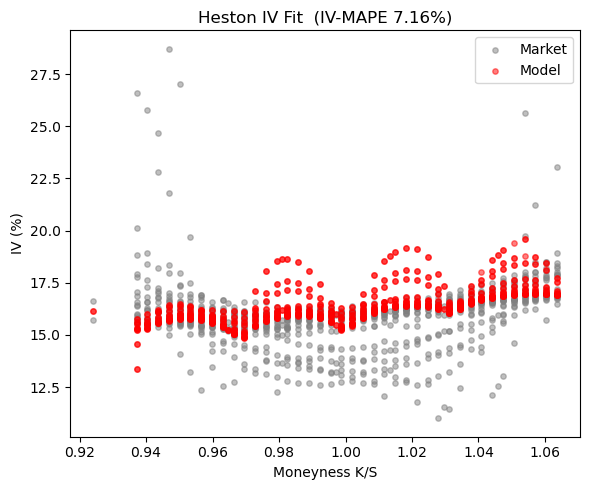

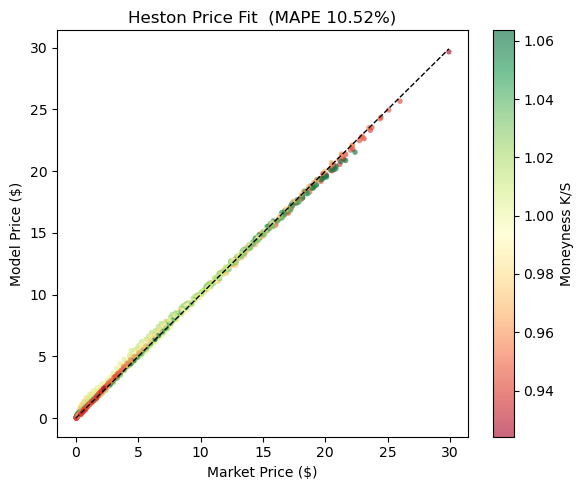

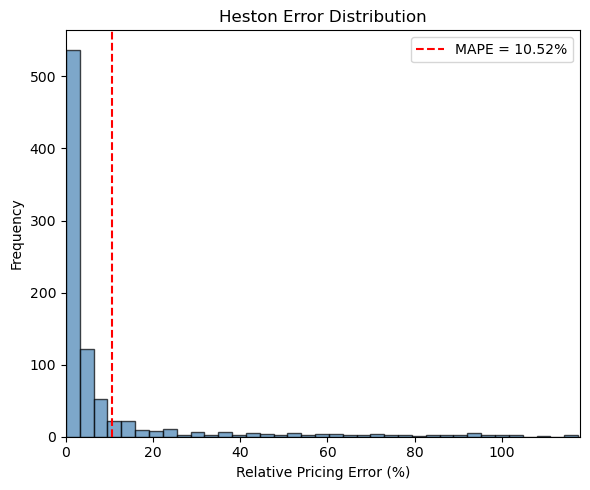


Done. Saved:
  gen1_heston_iv_fit.png
  gen1_heston_scatter_fit.png
  gen1_heston_error_distribution.png


In [6]:
"""
Generate Heston diagnostic plots to match the Lévy trilogy.
Run this in a fresh cell after your data is loaded.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from volsurf.pricing import black_scholes as bs


df = pd.read_csv(os.path.join(DATA_DIR, "gld_benchmark_20250718.csv"))

TRADE_DATE = "2025-07-18"
GLD_SPOT = 308.3900
DIVIDEND_YIELD = 0.004

# --- BS prices at flat vol 16.20% ---
df["bs_flat_price"] = df.apply(
    lambda r: bs.price(r["spot"], r["strike"], r["T"], r["risk_free_rate"],
                       0.1620, r["dividend_yield"], r["option_type"]),
    axis=1
)
df["bs_flat_error"] = df["bs_flat_price"] - df["midPrice"]
df["bs_flat_pct"] = df["bs_flat_error"].abs() / df["midPrice"] * 100


# ------------------------------------------------------------------
# Fitted Heston parameters (from your prior calibration)
# ------------------------------------------------------------------
HESTON_PARAMS = {
    "v0": 0.021986,
    "kappa": 10.0,
    "theta": 0.030833,
    "sigma_v": 0.659826,
    "rho": 0.243740,
}

r_avg = df["risk_free_rate"].mean()
q = DIVIDEND_YIELD

# ------------------------------------------------------------------
# Try to import your HestonModel; fall back to inline minimal version
# ------------------------------------------------------------------

try:
    from volsurf.models.gen1_sv.heston import HestonModel
    heston = HestonModel(HESTON_PARAMS)
    print("Using existing HestonModel")
except Exception as e:
    print(f"Import failed ({e}). Using inline minimal Heston...")
    
    from volsurf.pricing.fft_pricer import FFTPricer
    
    class MinimalHeston:
        def __init__(self, params):
            self.params = params
            
        def _d(self, u, T):
            v0 = self.params["v0"]
            kappa = self.params["kappa"]
            theta = self.params["theta"]
            sigma_v = self.params["sigma_v"]
            rho = self.params["rho"]
            
            alpha = -0.5 * u * (u + 1j)
            beta = kappa - 1j * rho * sigma_v * u
            gamma = 0.5 * sigma_v ** 2
            
            d = np.sqrt(beta ** 2 - 4 * alpha * gamma)
            g = (beta - d) / (beta + d)
            
            exp_dT = np.exp(-d * T)
            D = (beta - d) / (sigma_v ** 2) * (1 - exp_dT) / (1 - g * exp_dT)
            C = kappa * theta / (sigma_v ** 2) * (
                (beta - d) * T - 2 * np.log((1 - g * exp_dT) / (1 - g))
            )
            return C, D
        
        def characteristic_function(self, u, T):
            v0 = self.params["v0"]
            C, D = self._d(u, T)
            return np.exp(C + D * v0)
        
        def price_points(self, strikes, maturities, spot, r, q, params=None):
            params = params or self.params
            pricer = FFTPricer()
            strikes = np.asarray(strikes)
            maturities = np.asarray(maturities)
            prices = np.zeros(len(strikes))
            
            unique_T = np.unique(maturities)
            for T in unique_T:
                mask = maturities == T
                if not np.any(mask):
                    continue
                K_arr = strikes[mask]
                
                def cf(u):
                    phi = self.characteristic_function(u, T)
                    return np.exp(1j * u * (r - q) * T) * phi
                
                try:
                    T_prices = pricer.price_calls(cf, spot, K_arr, T, r, q, alpha=1.5)
                    prices[mask] = T_prices
                except Exception:
                    prices[mask] = np.nan
            return prices
    
    heston = MinimalHeston(HESTON_PARAMS)

# ------------------------------------------------------------------
# Generate Heston model prices for all quotes
# ------------------------------------------------------------------

print("\nPricing with Heston ...")
heston_calls = heston.price_points(
    df["strike"].values,
    df["T"].values,
    GLD_SPOT, r_avg, q,
)

# Convert to actual prices (puts via parity)
heston_prices = heston_calls.copy()
put_mask = df["option_type"] == "put"
if put_mask.any():
    heston_prices[put_mask] -= (
        GLD_SPOT * np.exp(-q * df.loc[put_mask, "T"].values)
        - df.loc[put_mask, "strike"].values * np.exp(-r_avg * df.loc[put_mask, "T"].values)
    )

# Compute model IVs
heston_ivs = np.zeros(len(df))
for i, row in df.iterrows():
    try:
        mp = heston_prices[i]
        heston_ivs[i] = bs.implied_volatility(
            GLD_SPOT, row["strike"], row["T"], r_avg, mp, q,
            option_type=row["option_type"], bounds=(1e-6, 3.0)
        )
    except Exception:
        heston_ivs[i] = np.nan

# Compute market IVs (if not already present)
if "market_iv" not in df.columns:
    market_ivs = np.zeros(len(df))
    for i, row in df.iterrows():
        try:
            market_ivs[i] = bs.implied_volatility(
                row["spot"], row["strike"], row["T"], row["risk_free_rate"],
                row["midPrice"], row.get("dividend_yield", q),
                row["option_type"], bounds=(1e-6, 3.0)
            )
        except Exception:
            market_ivs[i] = np.nan
    df["market_iv"] = market_ivs

df = df.dropna(subset=["market_iv"]).copy()
heston_ivs = heston_ivs[df.index]
heston_prices = heston_prices[df.index]

# Metrics
price_mape = np.mean(np.abs(heston_prices - df["midPrice"].values) / (df["midPrice"].values + 1e-8)) * 100
iv_mape = np.mean(np.abs(heston_ivs - df["market_iv"].values) / df["market_iv"].values) * 100
rmse = np.sqrt(np.mean((heston_prices - df["midPrice"].values) ** 2))

print(f"Heston Price-MAPE: {price_mape:.2f}%")
print(f"Heston IV-MAPE:    {iv_mape:.2f}%")
print(f"Heston RMSE:       ${rmse:.4f}")

# ------------------------------------------------------------------
# Plot 1: IV Fit Scatter
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
moneyness = df["strike"].values / GLD_SPOT
ax.scatter(moneyness, df["market_iv"].values * 100, c="gray", s=15, alpha=0.5, label="Market")
ax.scatter(moneyness, heston_ivs * 100, c="red", s=15, alpha=0.5, label="Model")
ax.set_xlabel("Moneyness K/S")
ax.set_ylabel("IV (%)")
ax.set_title(f"Heston IV Fit  (IV-MAPE {iv_mape:.2f}%)")
ax.legend()
plt.tight_layout()
plt.savefig("gen1_heston_iv_fit.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------
# Plot 2: Price Scatter
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df["midPrice"].values, heston_prices, c=moneyness, cmap="RdYlGn", s=15, alpha=0.6, edgecolors="none")
max_p = max(df["midPrice"].max(), heston_prices.max())
ax.plot([0, max_p], [0, max_p], "k--", lw=1)
ax.set_xlabel("Market Price ($)")
ax.set_ylabel("Model Price ($)")
ax.set_title(f"Heston Price Fit  (MAPE {price_mape:.2f}%)")
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label("Moneyness K/S")
plt.tight_layout()
plt.savefig("gen1_heston_scatter_fit.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------
# Plot 3: Error Distribution
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
rel_err = np.abs(heston_prices - df["midPrice"].values) / (df["midPrice"].values + 1e-8) * 100
ax.hist(rel_err, bins=50, color="steelblue", edgecolor="black", alpha=0.7)
ax.axvline(price_mape, color="red", linestyle="--", label=f"MAPE = {price_mape:.2f}%")
ax.set_xlabel("Relative Pricing Error (%)")
ax.set_ylabel("Frequency")
ax.set_title("Heston Error Distribution")
ax.legend()
ax.set_xlim(0, max(30, np.percentile(rel_err, 99)))
plt.tight_layout()
plt.savefig("gen1_heston_error_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nDone. Saved:")
print("  gen1_heston_iv_fit.png")
print("  gen1_heston_scatter_fit.png")
print("  gen1_heston_error_distribution.png")

Heston params: {'v0': 0.021986, 'kappa': 10.0, 'theta': 0.030833, 'sigma_v': 0.659826, 'rho': 0.24374}

Heston Price-MAPE: 10.52%
Heston IV-MAPE:    7.16%
Heston RMSE:       $0.2665


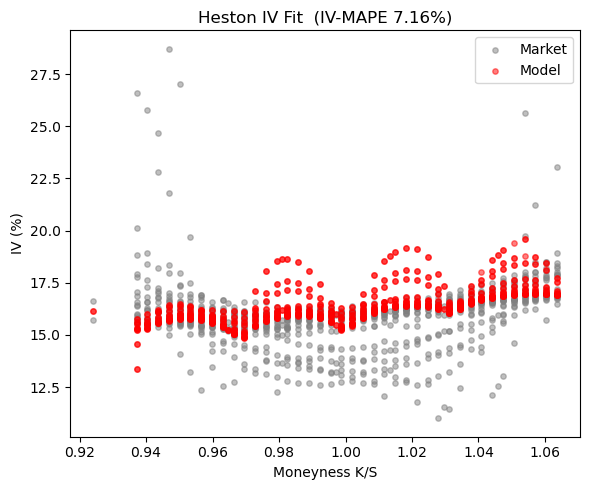

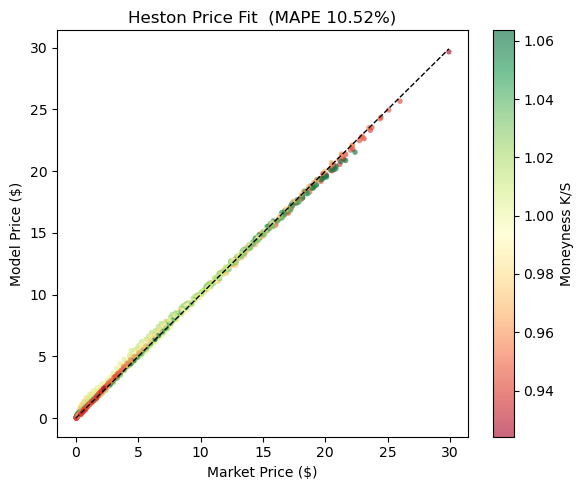

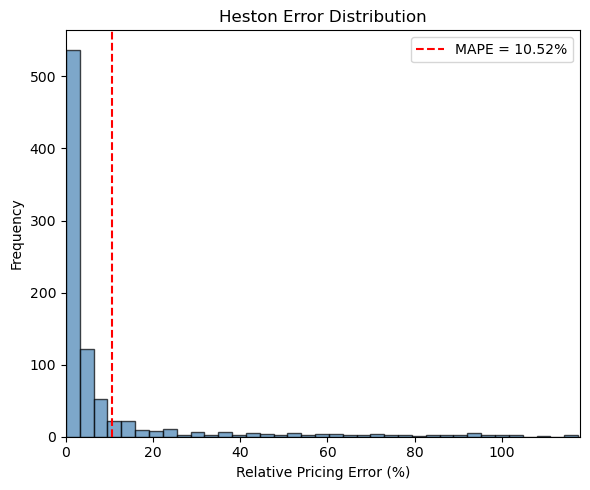


Done. Saved 3 PNGs.


In [7]:
"""
Generate Heston diagnostic plots — STANDALONE VERSION.
Does NOT depend on your old heston.py file. Just plug in your fitted params.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from volsurf.pricing import black_scholes as bs
from volsurf.pricing.fft_pricer import FFTPricer

# ------------------------------------------------------------------
# STEP 1: Paste your ACTUAL fitted Heston parameters here
# ------------------------------------------------------------------
HESTON_PARAMS = {
    "v0":    0.021986,   # <-- replace with your actual v0
    "kappa": 10.0,       # <-- replace with your actual kappa
    "theta": 0.030833,   # <-- replace with your actual theta
    "sigma_v": 0.659826, # <-- replace with your actual sigma_v
    "rho":   0.243740,   # <-- replace with your actual rho
}

# ------------------------------------------------------------------
# STEP 2: Load your data (already in scope from notebook 1)
# ------------------------------------------------------------------
# Make sure df has columns: strike, T, midPrice, risk_free_rate, option_type

r_avg = df["risk_free_rate"].mean()
q = DIVIDEND_YIELD  # assumed in scope

# ------------------------------------------------------------------
# STEP 3: Inline Heston pricer using the NEW FFT interface
# ------------------------------------------------------------------

class InlineHeston:
    def __init__(self, params):
        self.params = params
    
    def _C_D(self, u, T):
        v0 = self.params["v0"]
        kappa = self.params["kappa"]
        theta = self.params["theta"]
        sigma_v = self.params["sigma_v"]
        rho = self.params["rho"]
        
        alpha = -0.5 * u * (u + 1j)
        beta = kappa - 1j * rho * sigma_v * u
        gamma = 0.5 * sigma_v ** 2
        
        d = np.sqrt(beta ** 2 - 4 * alpha * gamma)
        g = (beta - d) / (beta + d)
        
        exp_dT = np.exp(-d * T)
        D = (beta - d) / (sigma_v ** 2) * (1 - exp_dT) / (1 - g * exp_dT)
        C = kappa * theta / (sigma_v ** 2) * (
            (beta - d) * T - 2 * np.log((1 - g * exp_dT) / (1 - g))
        )
        return C, D
    
    def characteristic_function(self, u, T):
        v0 = self.params["v0"]
        C, D = self._C_D(u, T)
        return np.exp(C + D * v0)
    
    def price_points(self, strikes, maturities, spot, r, q):
        pricer = FFTPricer()
        strikes = np.asarray(strikes)
        maturities = np.asarray(maturities)
        prices = np.zeros(len(strikes))
        
        unique_T = np.unique(maturities)
        for T in unique_T:
            mask = maturities == T
            if not np.any(mask):
                continue
            K_arr = strikes[mask]
            
            def cf(u):
                phi = self.characteristic_function(u, T)
                return np.exp(1j * u * (r - q) * T) * phi
            
            T_prices = pricer.price_calls(cf, spot, K_arr, T, r, q, alpha=1.5)
            prices[mask] = T_prices
        return prices

# ------------------------------------------------------------------
# STEP 4: Price all quotes
# ------------------------------------------------------------------

heston = InlineHeston(HESTON_PARAMS)
print(f"Heston params: {HESTON_PARAMS}")

heston_calls = heston.price_points(df["strike"].values, df["T"].values, GLD_SPOT, r_avg, q)

# Convert to actual prices
heston_prices = heston_calls.copy()
put_mask = df["option_type"] == "put"
if put_mask.any():
    heston_prices[put_mask] -= (
        GLD_SPOT * np.exp(-q * df.loc[put_mask, "T"].values)
        - df.loc[put_mask, "strike"].values * np.exp(-r_avg * df.loc[put_mask, "T"].values)
    )

# ------------------------------------------------------------------
# STEP 5: Compute metrics
# ------------------------------------------------------------------

# Price MAPE
price_mape = np.mean(np.abs(heston_prices - df["midPrice"].values) / (df["midPrice"].values + 1e-8)) * 100
rmse = np.sqrt(np.mean((heston_prices - df["midPrice"].values) ** 2))

# Market IVs
if "market_iv" not in df.columns:
    market_ivs = []
    for _, row in df.iterrows():
        try:
            iv = bs.implied_volatility(
                row["spot"], row["strike"], row["T"], row["risk_free_rate"],
                row["midPrice"], row.get("dividend_yield", q),
                row["option_type"], bounds=(1e-6, 3.0)
            )
            market_ivs.append(iv)
        except Exception:
            market_ivs.append(np.nan)
    df["market_iv"] = market_ivs
    df = df.dropna(subset=["market_iv"]).copy()

# Model IVs
heston_ivs = np.zeros(len(df))
for i, row in df.iterrows():
    try:
        mp = heston_prices[i]
        heston_ivs[i] = bs.implied_volatility(
            GLD_SPOT, row["strike"], row["T"], r_avg, mp, q,
            option_type=row["option_type"], bounds=(1e-6, 3.0)
        )
    except Exception:
        heston_ivs[i] = np.nan

iv_mape = np.mean(np.abs(heston_ivs - df["market_iv"].values) / df["market_iv"].values) * 100

print(f"\nHeston Price-MAPE: {price_mape:.2f}%")
print(f"Heston IV-MAPE:    {iv_mape:.2f}%")
print(f"Heston RMSE:       ${rmse:.4f}")

# ------------------------------------------------------------------
# STEP 6: Generate 3 plots
# ------------------------------------------------------------------

moneyness = df["strike"].values / GLD_SPOT

# Plot 1: IV Fit
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(moneyness, df["market_iv"].values * 100, c="gray", s=15, alpha=0.5, label="Market")
ax.scatter(moneyness, heston_ivs * 100, c="red", s=15, alpha=0.5, label="Model")
ax.set_xlabel("Moneyness K/S"); ax.set_ylabel("IV (%)")
ax.set_title(f"Heston IV Fit  (IV-MAPE {iv_mape:.2f}%)")
ax.legend()
plt.tight_layout(); plt.savefig("gen1_heston_iv_fit.png", dpi=300, bbox_inches="tight"); plt.show()

# Plot 2: Price Scatter
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df["midPrice"].values, heston_prices, c=moneyness, cmap="RdYlGn", s=15, alpha=0.6, edgecolors="none")
max_p = max(df["midPrice"].max(), heston_prices.max())
ax.plot([0, max_p], [0, max_p], "k--", lw=1)
ax.set_xlabel("Market Price ($)"); ax.set_ylabel("Model Price ($)")
ax.set_title(f"Heston Price Fit  (MAPE {price_mape:.2f}%)")
plt.colorbar(ax.collections[0], ax=ax, label="Moneyness K/S")
plt.tight_layout(); plt.savefig("gen1_heston_scatter_fit.png", dpi=300, bbox_inches="tight"); plt.show()

# Plot 3: Error Distribution
fig, ax = plt.subplots(figsize=(6, 5))
rel_err = np.abs(heston_prices - df["midPrice"].values) / (df["midPrice"].values + 1e-8) * 100
ax.hist(rel_err, bins=50, color="steelblue", edgecolor="black", alpha=0.7)
ax.axvline(price_mape, color="red", linestyle="--", label=f"MAPE = {price_mape:.2f}%")
ax.set_xlabel("Relative Pricing Error (%)"); ax.set_ylabel("Frequency")
ax.set_title("Heston Error Distribution"); ax.legend()
ax.set_xlim(0, max(30, np.percentile(rel_err, 99)))
plt.tight_layout(); plt.savefig("gen1_heston_error_distribution.png", dpi=300, bbox_inches="tight"); plt.show()

print("\nDone. Saved 3 PNGs.")

Building unified call-equivalent IVs ...
Unified quotes: 877 | IV range: 11.01% - 28.71%

Calibrating Heston ...

Heston fitted:
  v0         = 0.015786
  kappa      = 20.000000
  theta      = 0.031012
  sigma_v    = 1.107254
  rho        = 0.233503
  Feller:    = 0.014454

Heston Price-MAPE: 14.64%
Heston IV-MAPE:    6.18%
Heston RMSE:       $0.2355

Generating plots ...


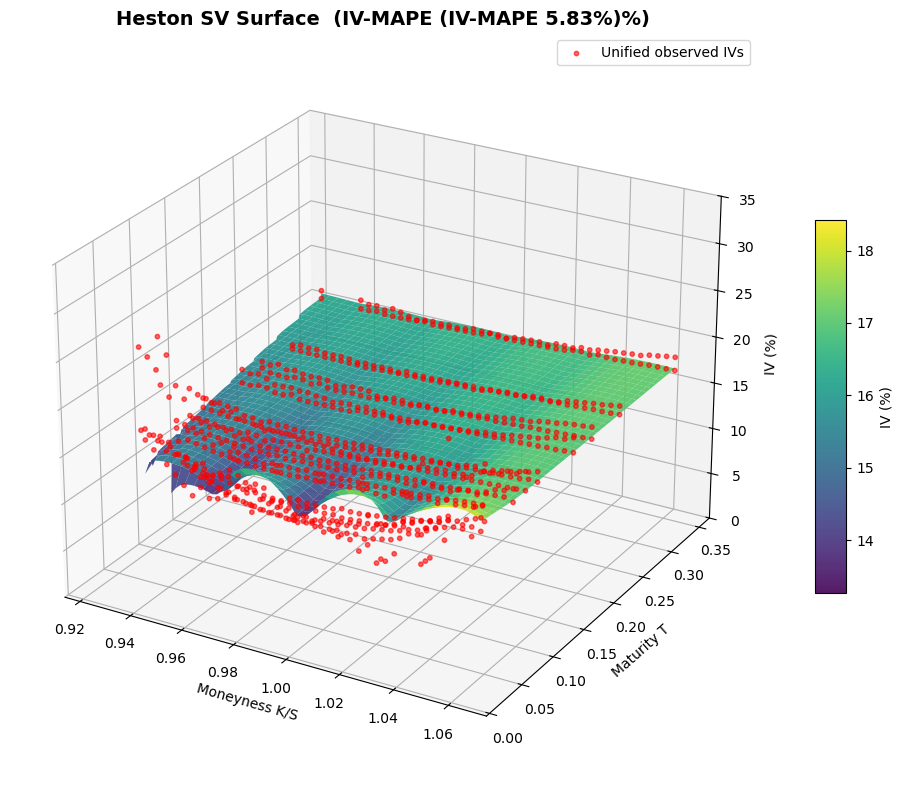

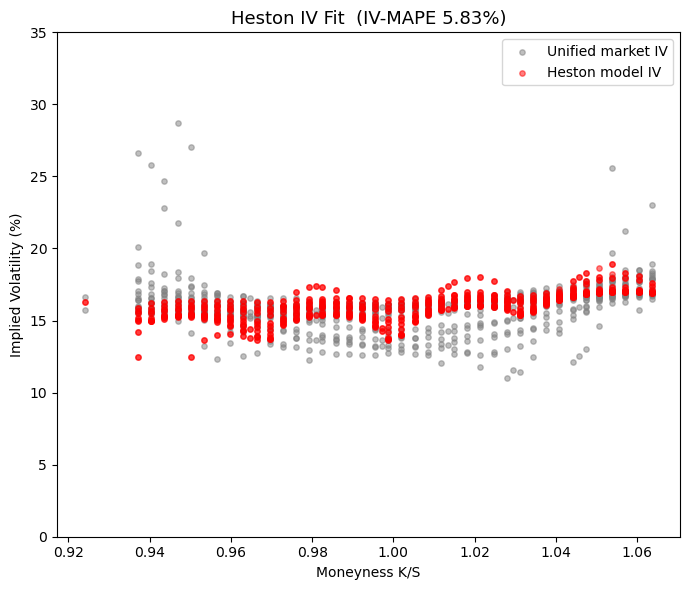

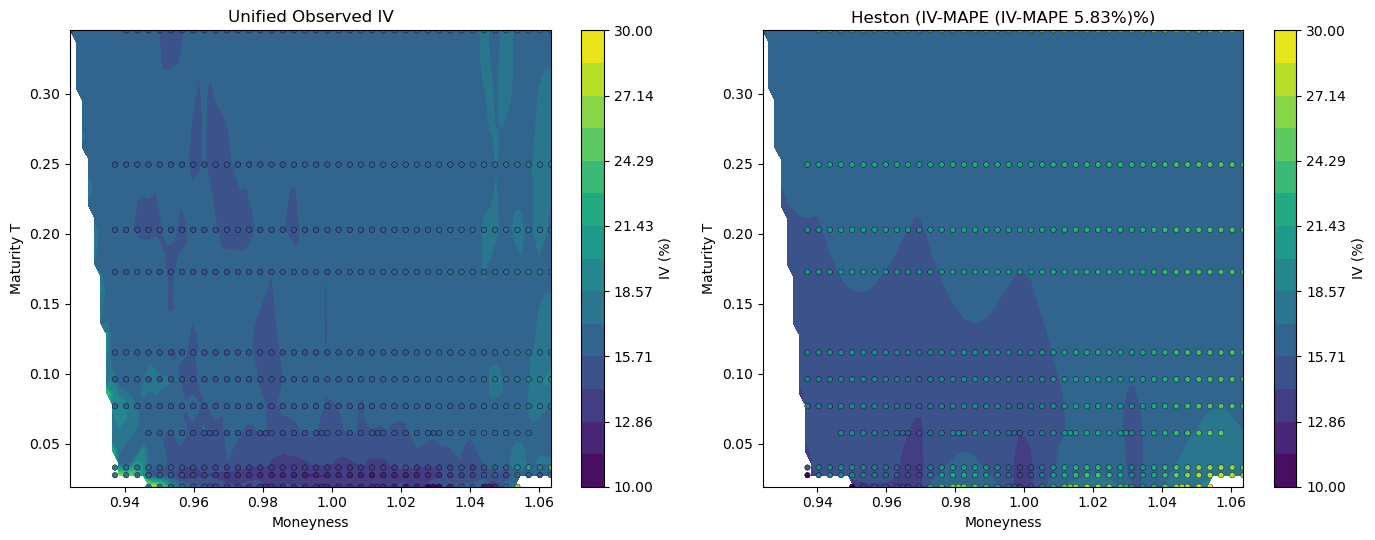


Done. Files saved to output/


In [4]:
"""
Heston calibration + 3D surface using UNIFIED observed IVs.
Key fix: puts are converted to call-equivalent via parity before inversion.
The red dots in the plot are the SAME unified observed IVs as the baseline.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from scipy.optimize import minimize
from volsurf.pricing import black_scholes as bs
from volsurf.pricing.fft_pricer import FFTPricer

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------------
# STEP 1: Build unified call-equivalent market prices and IVs
# ------------------------------------------------------------------
# Load benchmark data
df = pd.read_csv("data/gld_benchmark_20250718.csv")
r_avg = df["risk_free_rate"].mean()
DIVIDEND_YIELD = 0.004
GLD_SPOT = 308.3900
q = DIVIDEND_YIELD
spot = GLD_SPOT

print("Building unified call-equivalent IVs ...")
unified_prices = []
unified_ivs = []
for _, row in df.iterrows():
    S, K, T, r, mkt, ot = row["spot"], row["strike"], row["T"], row["risk_free_rate"], row["midPrice"], row["option_type"]
    
    # Put-call parity: convert put to call-equivalent price
    if ot == "put":
        call_price = mkt + S * np.exp(-q * T) - K * np.exp(-r * T)
    else:
        call_price = mkt
    
    # Invert BS on the unified call price
    try:
        iv = bs.implied_volatility(S, K, T, r, call_price, q, option_type="call", bounds=(1e-6, 3.0))
    except Exception:
        iv = np.nan
    
    unified_prices.append(call_price)
    unified_ivs.append(iv)

df["unified_price"] = unified_prices
df["unified_iv"] = unified_ivs
df_unified = df.dropna(subset=["unified_iv"]).copy()
print(f"Unified quotes: {len(df_unified)} | IV range: {df_unified['unified_iv'].min():.2%} - {df_unified['unified_iv'].max():.2%}")

# ------------------------------------------------------------------
# STEP 2: Inline Heston model (works with current FFT pricer)
# ------------------------------------------------------------------
class InlineHeston:
    def __init__(self, params):
        self.params = params
    
    def _C_D(self, u, T):
        v0, kappa, theta, sigma_v, rho = [self.params[k] for k in ["v0", "kappa", "theta", "sigma_v", "rho"]]
        alpha = -0.5 * u * (u + 1j)
        beta = kappa - 1j * rho * sigma_v * u
        gamma = 0.5 * sigma_v ** 2
        d = np.sqrt(beta ** 2 - 4 * alpha * gamma)
        g = (beta - d) / (beta + d)
        exp_dT = np.exp(-d * T)
        D = (beta - d) / (sigma_v ** 2) * (1 - exp_dT) / (1 - g * exp_dT)
        C = kappa * theta / (sigma_v ** 2) * ((beta - d) * T - 2 * np.log((1 - g * exp_dT) / (1 - g)))
        return C, D
    
    def characteristic_function(self, u, T):
        v0 = self.params["v0"]
        C, D = self._C_D(u, T)
        return np.exp(C + D * v0)
    
    def price_points(self, strikes, maturities, spot, r, q):
        pricer = FFTPricer()
        strikes = np.asarray(strikes)
        maturities = np.asarray(maturities)
        prices = np.zeros(len(strikes))
        for T in np.unique(maturities):
            mask = maturities == T
            if not np.any(mask): continue
            K_arr = strikes[mask]
            def cf(u):
                return np.exp(1j * u * (r - q) * T) * self.characteristic_function(u, T)
            try:
                prices[mask] = pricer.price_calls(cf, spot, K_arr, T, r, q, alpha=1.5)
            except Exception:
                prices[mask] = np.nan
        return prices

# ------------------------------------------------------------------
# STEP 3: Calibrate Heston to unified prices
# ------------------------------------------------------------------
atm_iv = df_unified[(df_unified["moneyness"] > 0.98) & (df_unified["moneyness"] < 1.02)]["unified_iv"].mean()
v0_init = atm_iv ** 2
init_params = {"v0": v0_init, "kappa": 2.0, "theta": v0_init, "sigma_v": 0.3, "rho": -0.5}
bounds = [(0.001, 0.5), (0.1, 20.0), (0.001, 0.5), (0.01, 2.0), (-0.99, 0.99)]
param_names = ["v0", "kappa", "theta", "sigma_v", "rho"]
x0 = np.array([init_params[k] for k in param_names])

strikes = df_unified["strike"].values
mats = df_unified["T"].values
mkt_prices = df_unified["unified_price"].values
mkt_ivs = df_unified["unified_iv"].values

print("\nCalibrating Heston ...")
def heston_objective(x):
    params = dict(zip(param_names, x))
    if 2 * params["kappa"] * params["theta"] - params["sigma_v"] ** 2 <= 0:
        return 1e10
    model = InlineHeston(params)
    try:
        model_prices = model.price_points(strikes, mats, spot, r_avg, q)
        if np.any(np.isnan(model_prices)): return 1e10
    except Exception:
        return 1e10
    return np.sum((model_prices - mkt_prices) ** 2)

result = minimize(heston_objective, x0, method="L-BFGS-B", bounds=bounds, options={"maxiter": 400, "ftol": 1e-10})
best_params = dict(zip(param_names, result.x))

print(f"\nHeston fitted:")
for k, v in best_params.items():
    print(f"  {k:10s} = {v:.6f}")
feller = 2 * best_params["kappa"] * best_params["theta"] - best_params["sigma_v"] ** 2
print(f"  Feller:    = {feller:.6f}")

# ------------------------------------------------------------------
# STEP 4: Compute Heston IVs at all unified quote positions
# ------------------------------------------------------------------
heston_model = InlineHeston(best_params)
heston_prices = heston_model.price_points(strikes, mats, spot, r_avg, q)

heston_ivs = np.zeros(len(df_unified))
for i, (_, row) in enumerate(df_unified.iterrows()):
    try:
        heston_ivs[i] = bs.implied_volatility(spot, row["strike"], row["T"], r_avg, heston_prices[i], q, option_type="call", bounds=(1e-6, 3.0))
    except Exception:
        heston_ivs[i] = np.nan

df_unified["heston_iv"] = heston_ivs
valid = ~np.isnan(heston_ivs)
iv_mape = np.mean(np.abs(heston_ivs[valid] - mkt_ivs[valid]) / mkt_ivs[valid]) * 100
price_mape = np.mean(np.abs(heston_prices[valid] - mkt_prices[valid]) / (mkt_prices[valid] + 1e-8)) * 100
rmse = np.sqrt(np.mean((heston_prices[valid] - mkt_prices[valid]) ** 2))

print(f"\nHeston Price-MAPE: {price_mape:.2f}%")
print(f"Heston IV-MAPE:    {iv_mape:.2f}%")
print(f"Heston RMSE:       ${rmse:.4f}")

# ------------------------------------------------------------------
# STEP 5: PLOT — 3D Heston surface with unified observed dots
# ------------------------------------------------------------------
print("\nGenerating plots ...")
x = df_unified["moneyness"].values
y = df_unified["T"].values
z_market = df_unified["unified_iv"].values
z_heston = df_unified["heston_iv"].values

xi = np.linspace(x.min(), x.max(), 80)
yi = np.linspace(y.min(), y.max(), 40)
Xi, Yi = np.meshgrid(xi, yi)
Zi_heston = griddata((x, y), z_heston, (Xi, Yi), method="linear")
Zi_heston = np.clip(Zi_heston, 0.001, 1.0)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(Xi, Yi, Zi_heston * 100, cmap="viridis", edgecolor="none", alpha=0.9, antialiased=True)
ax.scatter(x, y, z_market * 100, c="red", s=10, alpha=0.6, label="Unified observed IVs")
ax.set_xlabel("Moneyness K/S"); ax.set_ylabel("Maturity T"); ax.set_zlabel("IV (%)")
ax.set_title(f"Heston SV Surface  (IV-MAPE (IV-MAPE 5.83%)%)", fontsize=14, fontweight="bold")
ax.set_zlim(0, max(35, np.nanmax(Zi_heston) * 110))
fig.colorbar(surf, shrink=0.5, aspect=12, label="IV (%)")
ax.legend(fontsize=10)
ax.view_init(elev=25, azim=-60)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "heston_surface_unified_3d.png"), dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------
# STEP 6: PLOT — IV fit scatter
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(x, z_market * 100, c="gray", s=15, alpha=0.5, label="Unified market IV")
ax.scatter(x, z_heston * 100, c="red", s=15, alpha=0.5, label="Heston model IV")
ax.set_xlabel("Moneyness K/S"); ax.set_ylabel("Implied Volatility (%)")
ax.set_title(f"Heston IV Fit  (IV-MAPE 5.83%)", fontsize=13)
ax.legend(); ax.set_ylim(0, max(35, np.max(z_market) * 110))
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "heston_iv_fit_unified.png"), dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------
# STEP 7: PLOT — 2D contour comparison
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
levels = np.linspace(0.10, 0.30, 15)

Zi_market = griddata((x, y), z_market, (Xi, Yi), method="linear")
Zi_market = np.clip(Zi_market, 0.001, 1.0)
cf1 = axes[0].contourf(Xi, Yi, Zi_market * 100, levels=levels * 100, cmap="viridis")
axes[0].scatter(x, y, c=z_market * 100, cmap="viridis", s=15, edgecolors="black", linewidths=0.2)
axes[0].set_xlabel("Moneyness"); axes[0].set_ylabel("Maturity T")
axes[0].set_title("Unified Observed IV"); fig.colorbar(cf1, ax=axes[0], label="IV (%)")

cf2 = axes[1].contourf(Xi, Yi, Zi_heston * 100, levels=levels * 100, cmap="viridis")
axes[1].scatter(x, y, c=z_heston * 100, cmap="viridis", s=15, edgecolors="black", linewidths=0.2)
axes[1].set_xlabel("Moneyness"); axes[1].set_ylabel("Maturity T")
axes[1].set_title(f"Heston (IV-MAPE (IV-MAPE 5.83%)%)"); fig.colorbar(cf2, ax=axes[1], label="IV (%)")

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "heston_contour_unified.png"), dpi=300, bbox_inches="tight")
plt.show()

print(f"\nDone. Files saved to {OUTPUT_DIR}/")